In [1]:
import sys
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import torch
sys.path.insert(0, '/home/bnc2119/MEDAL')
from medal.eval_utils import load_and_split, get_teacher_embeddings
from medal.core import AutoEncoder
import matplotlib.colors as mcolors
from pathlib import Path
import matplotlib.ticker as ticker
from sklearn.model_selection import train_test_split
PATH_PREFIX = '/share/ctn/users/bnc2119' 
%load_ext autoreload
%autoreload 2

/home/bnc2119/.conda/envs/medal/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-03-30 13:25:18,200	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-03-30 13:25:18,791	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [2]:
hydra_X_og, hydra_X_test, hydra_y_og, hydra_y_test = load_and_split("hydra", test_size=0.2, seed=0, labels=True)
hydra_X, hydra_X_val, hydra_y, hydra_y_val = train_test_split(hydra_X_og, hydra_y_og, test_size=0.2, random_state=0)
mnist_X_og, mnist_X_test, mnist_y_og, mnist_y_test = load_and_split("mnist", test_size=0.2, seed=0, labels=True)
mnist_X, mnist_X_val, mnist_y, mnist_y_val = train_test_split(mnist_X_og, mnist_y_og, test_size=0.2, random_state=0)
label_colors = [plt.get_cmap("tab20")(i) for i in range(10)]
mnist_palette = {digit: col for digit, col in zip(mnist_y.value_counts().index, label_colors)}

hydra_palette = color_map = {
    "enEp_tentacle": "#1e3a8a",
    "enEp_stem_cell": "#1d4ed8",
    "enEp_foot": "#2563eb",
    "enEp_head": "#3b82f6",
    "enEp-nb(pd)": "#60a5fa",
    "enEp-nem(pd)": "#93c5fd",
    "enEp_tent-nem(pd)": "#bfdbfe",
    "ecEp-nb(pd)": "#134e4a",
    "ecEp_battery_cell2(mp)": "#0f766e",
    "ecEp_stem_cell": "#0d9488",
    "ecEp_head": "#14b8a6",
    "ecEp-nem(id)": "#2dd4bf",
    "ecEp_basal_disk": "#5eead4",
    "ecEp_battery_cell1(mp)": "#99f6e4",
    "i_stem_cell/progenitor": "#4a044e",
    "i_neuron/gland_cell_progenitor": "#6b21a8",
    "i_neuron_progenitor": "#7e22ce",
    "i_nb1": "#7c2d12",
    "i_nb2": "#c2410c",
    "i_nb3": "#ea580c",
    "i_nb4": "#f97316",
    "i_nb5": "#fb923c",
    "i_neuron_ec1": "#831843",
    "i_neuron_ec2": "#be185d",
    "i_neuron_ec3": "#db2777",
    "i_neuron_ec4": "#ec4899",
    "i_neuron_ec5": "#f472b6",
    "i_neuron_en1": "#3b0764",
    "i_neuron_en2": "#5b21b6",
    "i_neuron_en3": "#7c3aed",
    "i_female_germline1": "#312e81",
    "i_female_germline2_nurse": "#4338ca",
    "i_male_germline": "#818cf8",
    "i_granular_mucous_gland_cell": "#7f1d1d",
    "i_zymogen_gland_cell": "#b91c1c",
    "i_spumous_mucous_gland_cell": "#ef4444",
    "i_nematocyte": "#92400e",
    "db": "#d97706",
}

Text(0.5, 0.98, 'Manifold are sensitive to hyperparameters and random seed')

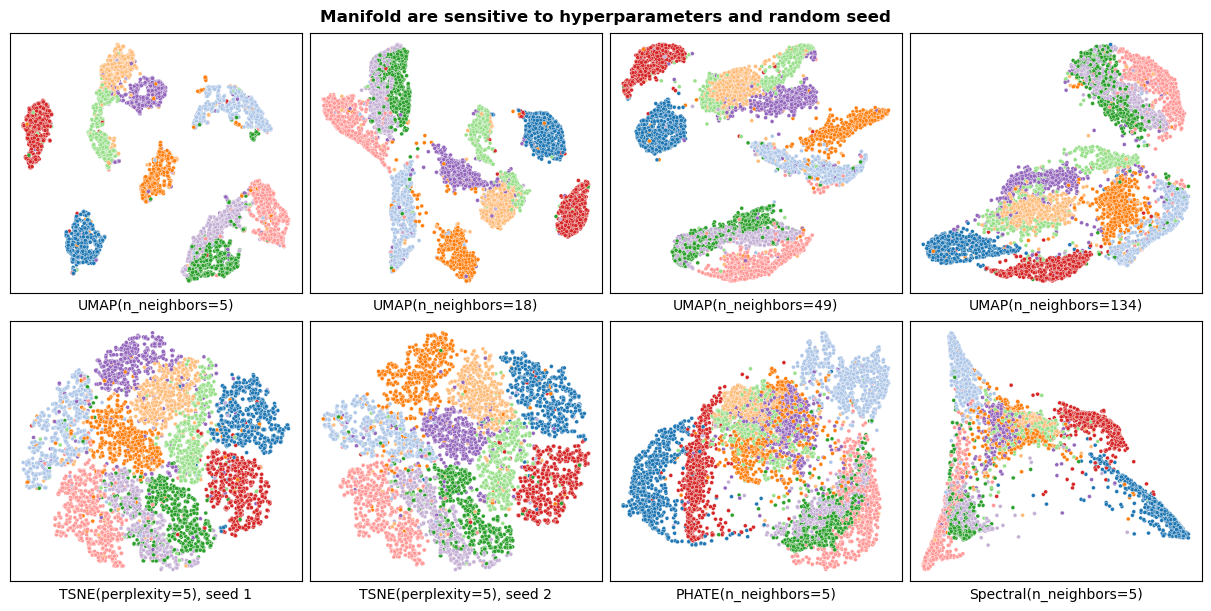

In [9]:
# MNIST
mnist_umap_embed1 = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/mnist_umap_5_0.1_0_train.npy")
mnist_umap_embed2 = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/mnist_umap_18_0.1_0_train.npy")
mnist_umap_embed3 = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/mnist_umap_49_0.1_0_train.npy")
mnist_umap_embed4 = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/mnist_umap_134_0.1_0_train.npy")

mnist_tsne_embed1 = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/mnist_tsne_5_10_train.npy")
mnist_tsne_embed2 = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/mnist_tsne_5_0_train.npy")
mnist_phate_embed = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/mnist_phate2_5_0_train.npy")
mnist_spectral_embed = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/mnist_spectral_5_0_train.npy")

fig, axes = plt.subplots(2, 4, figsize=(12,6), constrained_layout = True)
axes_flat = axes.flatten()

# ROW 1
sns.scatterplot(x = mnist_umap_embed1[:, 0], y = mnist_umap_embed1[:, 1], hue = mnist_y, palette = mnist_palette, ax = axes_flat[0], legend = False, s = 8)
axes_flat[0].set_xlabel("UMAP(n_neighbors=5)")

sns.scatterplot(x = mnist_umap_embed2[:, 0], y = mnist_umap_embed2[:, 1], hue = mnist_y, palette = mnist_palette, ax = axes_flat[1], legend = False, s = 8)
axes_flat[1].set_xlabel("UMAP(n_neighbors=18)")

sns.scatterplot(x = mnist_umap_embed3[:, 0], y = mnist_umap_embed3[:, 1], hue = mnist_y, palette = mnist_palette, ax = axes_flat[2], legend = False, s = 8)
axes_flat[2].set_xlabel("UMAP(n_neighbors=49)")

sns.scatterplot(x = mnist_umap_embed4[:, 0], y = mnist_umap_embed4[:, 1], hue = mnist_y, palette = mnist_palette, ax = axes_flat[3], legend = False, s = 8)
axes_flat[3].set_xlabel("UMAP(n_neighbors=134)")

sns.scatterplot(x = mnist_tsne_embed1[:, 0], y = mnist_tsne_embed1[:, 1], hue = mnist_y, palette = mnist_palette, ax = axes_flat[4], legend = False, s = 8)
axes_flat[4].set_xlabel("TSNE(perplexity=5), seed 1")
sns.scatterplot(x = mnist_tsne_embed2[:, 0], y = mnist_tsne_embed2[:, 1], hue = mnist_y, palette = mnist_palette, ax = axes_flat[5], legend = False, s = 8)
axes_flat[5].set_xlabel("TSNE(perplexity=5), seed 2")

sns.scatterplot(x = mnist_phate_embed[:, 0], y = mnist_phate_embed[:, 1], hue = mnist_y, palette = mnist_palette, ax = axes_flat[6], legend = False, s = 8)
axes_flat[6].set_xlabel("PHATE(n_neighbors=5)")

sns.scatterplot(x = mnist_spectral_embed[:, 0], y = mnist_spectral_embed[:, 1], hue = mnist_y, palette = mnist_palette, ax = axes_flat[7], legend = False, s = 8)
axes_flat[7].set_xlabel("Spectral(n_neighbors=5)")

for ax in axes_flat:
    ax.tick_params(axis='both', which='both', length=0, labelbottom=False, labelleft=False)
fig.suptitle("Manifold are sensitive to hyperparameters and random seed", fontweight='bold')


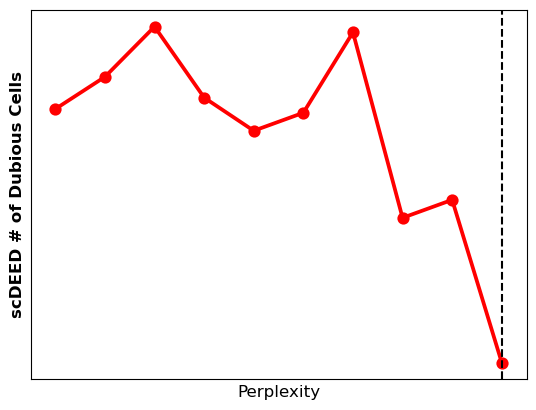

In [11]:
scdeed_analysis = pd.read_csv(Path(PATH_PREFIX) / 'MEDAL/comparisons/results_scdeed_tsne/seed0/tsne_best_hydra_train_num_dubious.csv')
umap_argmin = scdeed_analysis['number_dubious_cells'].idxmin()
argmin_position = scdeed_analysis.index.tolist().index(umap_argmin)

sns.pointplot(data=scdeed_analysis, x='perplexity', y='number_dubious_cells', color='red')
plt.axvline(x = argmin_position, ls = '--', c ='black')
plt.ylabel("scDEED # of Dubious Cells", fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xlabel("Perplexity", fontsize=12)
plt.xticks([])
plt.yticks([])
plt.setp(plt.gca().get_xticklabels(), rotation=45, ha='center')

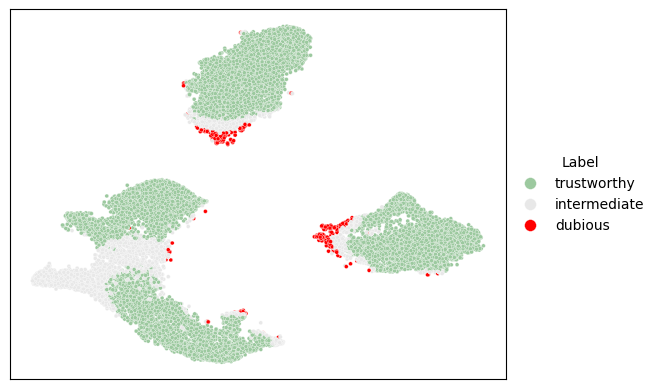

In [20]:
def split_scdeed_labels(df, best_param):
    result = []
    for l in ["dubious", "trustworthy", "intermediate"]:
        vec = df.loc[best_param, f"{l}_cells"]
        if vec == 'none':
            continue
        ls_indices = np.array(vec.split(',')).astype(int)
        result.extend(list(zip([l]* len(ls_indices), ls_indices)))
    return pd.DataFrame(result, columns = ['label', 'index']).set_index('index').sort_index()
scdeed_df1 = pd.read_csv(Path(PATH_PREFIX) / "MEDAL/comparisons/results_scdeed_tsne/seed0/tsne_best_hydra_train_full_results.csv", index_col=0)
per_sample_scdeed1 = split_scdeed_labels(scdeed_df1, 499)['label']
palette_scdeed = {'dubious': 'red', 'intermediate': '#e8e8e8', 'trustworthy': "#9cc99f"}
teacher_embed = np.load(Path(PATH_PREFIX) / f"MEDAL/comparisons/data/hydra_train_tsne_499_0_train_pc4.npy")
sns.scatterplot(x=teacher_embed[:, 0], y=teacher_embed[:, 1], 
                s=8, hue = per_sample_scdeed1, palette = palette_scdeed, legend=True)

plt.legend(loc='center', bbox_to_anchor=(1.15, 0.5), 
           frameon=False, title='Label', ncol=1, fontsize=10, markerscale=3, title_fontsize=10)
plt.xticks([])
plt.yticks([])
plt.show()

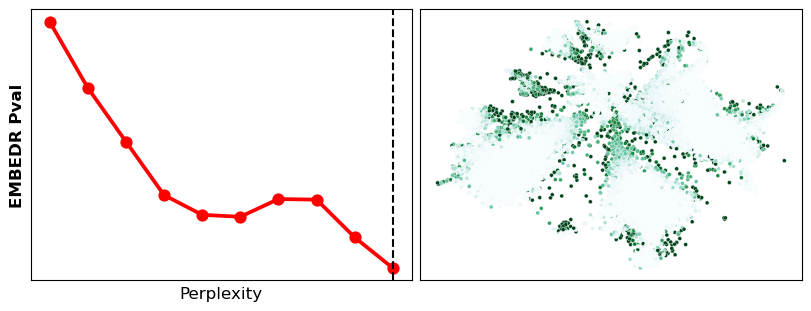

In [31]:
# showing that scdeed is inconsistent
embedr_1_best = 4999
teacher_embed = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings/hydra_tsne_{embedr_1_best}_0_train_embedr.npy").squeeze(0)

embedr_df1 = pd.read_csv(Path(PATH_PREFIX) / 'MEDAL/comparisons/results_embedr_tsne_seed0/hydra_train/X_with_best_scores.csv')
per_sample_embedr1 = embedr_df1[f'embedr_pval_meanbest_{embedr_1_best}']

embedr_analysis1 = pd.read_csv(Path(PATH_PREFIX) / 'MEDAL/comparisons/results_embedr_tsne_seed0/hydra_train/elbow_df.csv',  index_col = 0)
embedr_tsne_argmin = embedr_analysis1.groupby('perplexity')['mean_embedr_pval'].mean().idxmin()
argmin_position1 = embedr_analysis1.index.tolist().index(embedr_tsne_argmin)

fig, axes = plt.subplots(1,2, figsize=(8, 3), constrained_layout=True)
axes_flat = axes.flatten()
cmap = sns.color_palette("BuGn", as_cmap=True)

# 1st row 
sns.pointplot(data=embedr_analysis1, x='perplexity', y='mean_embedr_pval', color='red',ax = axes_flat[0])
axes_flat[0].axvline(x = argmin_position1, ls = '--', c ='black')
axes_flat[0].set_ylabel("EMBEDR Pval", fontsize=12, fontweight='bold')
axes_flat[0].set_xlabel("Perplexity", fontsize=12)
# 2nd row 
sns.scatterplot(x=teacher_embed[:, 0], y=teacher_embed[:, 1], 
                ax=axes_flat[1], s=8, hue = per_sample_embedr1, palette=cmap, 
                hue_norm=plt.Normalize(vmin=np.quantile(per_sample_embedr1, 0.025), vmax=np.quantile(per_sample_embedr1, 0.975)), 
                legend=False, rasterized=True)

for ax in axes_flat:
    ax.set_xticks([])
    ax.set_yticks([])
    
plt.show()

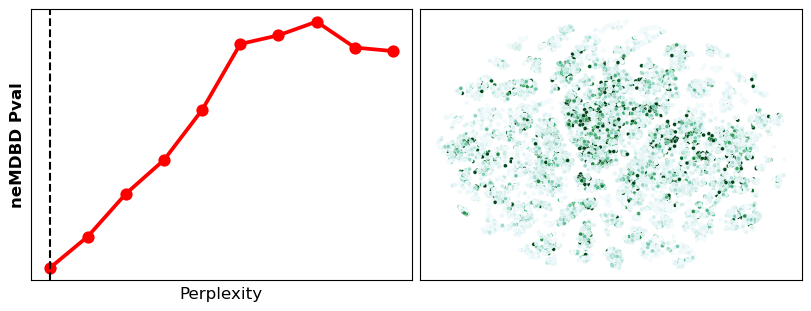

In [30]:
# showing that scdeed is inconsistent
embedr_1_best = 5
teacher_embed = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings/hydra_tsne_{embedr_1_best}_0_train_pcs.npy")

embedr_df1 = pd.read_csv(Path(PATH_PREFIX) / 'MEDAL/comparisons/results_pcs_seed0/hydra_train/X_with_best_scores.csv')
per_sample_embedr1 = embedr_df1[f'sscore_meanbest_5']

embedr_analysis1 = pd.read_csv(Path(PATH_PREFIX) / 'MEDAL/comparisons/results_pcs_seed0/hydra_train/elbow_df.csv',  index_col = 0)
embedr_tsne_argmin = embedr_analysis1.groupby('perplexity')['mean_sscore'].mean().idxmin()
argmin_position1 = embedr_analysis1.index.tolist().index(embedr_tsne_argmin)

fig, axes = plt.subplots(1,2, figsize=(8, 3), constrained_layout=True)
axes_flat = axes.flatten()
cmap = sns.color_palette("BuGn", as_cmap=True)

# 1st row 
sns.pointplot(data=embedr_analysis1, x='perplexity', y='mean_sscore', color='red', ax = axes_flat[0])
axes_flat[0].axvline(x = argmin_position1, ls = '--', c ='black')
axes_flat[0].set_ylabel("neMDBD Pval", fontsize=12, fontweight='bold')
axes_flat[0].set_xlabel("Perplexity", fontsize=12)
# 2nd row 
sns.scatterplot(x=teacher_embed[:, 0], y=teacher_embed[:, 1], 
                ax=axes_flat[1], s=8, hue = per_sample_embedr1, palette=cmap, 
                hue_norm=plt.Normalize(vmin=np.quantile(per_sample_embedr1, 0.025), vmax=np.quantile(per_sample_embedr1, 0.975)), 
                legend=False, rasterized=True)

for ax in axes_flat:
    ax.set_xticks([])
    ax.set_yticks([])
    
plt.show()

In [14]:
def load_trained_ae(ckpt_path, input_dim, hidden_dims,activation=torch.nn.SELU, latent_dim=2, batchnorm=False):
    import sys, os
    old_stdout = sys.stdout
    sys.stdout = open(os.devnull, "w")
    model = AutoEncoder(
        input_dim=input_dim,
        latent_dim=latent_dim,
        hidden_dims=hidden_dims,
        activation=activation,            
        bottleneck_activation=None,
        use_batchnorm = batchnorm
    )
    sys.stdout = old_stdout

    sd = torch.load(ckpt_path, map_location="cpu")

    # unwrap to the real state dict
    if isinstance(sd, dict) and "model" in sd and isinstance(sd["model"], dict):
        sd = sd["model"]
    elif isinstance(sd, dict) and "state_dict" in sd and isinstance(sd["state_dict"], dict):
        sd = sd["state_dict"]

    # remove DDP prefixes if any
    sd = {k.replace("module.", ""): v for k, v in sd.items()}

    # load STRICTLY so we fail fast if something doesn’t match
    missing, unexpected = model.load_state_dict(sd, strict=False)
    print(f"loaded params: {len(sd)} | missing={len(missing)} | unexpected={len(unexpected)}")
    if missing or unexpected:
        print("⚠️ Check architecture/keys. Example missing:", missing[:3], "unexpected:", unexpected[:3])

    model.eval()
    return model

def split_scdeed_labels(df, best_param):
    result = []
    for l in ["dubious", "trustworthy", "intermediate"]:
        vec = df.loc[best_param, f"{l}_cells"]
        if vec == 'none':
            continue
        ls_indices = np.array(vec.split(',')).astype(int)
        result.extend(list(zip([l]* len(ls_indices), ls_indices)))
    return pd.DataFrame(result, columns = ['label', 'index']).set_index('index').sort_index()

import numpy as np

def jaccard_curve(scores_runs, quantiles):

    jaccard_curve = []
    core_curve = []

    for q in quantiles:
        threshold_sets = [scores_runs[s] >= np.quantile(scores_runs[s], q) for s in scores_runs]

        inter = np.logical_and.reduce(threshold_sets).sum()
        union = np.logical_or.reduce(threshold_sets).sum()
        set_sizes = np.array([x.sum() for x in threshold_sets], dtype=float)
        mean_set_size = set_sizes.mean()

        print(f"q={q:0.3f}, inter={inter}, union={union}, mean_set_size={mean_set_size:.1f}")

        j3 = inter / union if union > 0 else 0.0
        core = inter / mean_set_size if mean_set_size > 0 else 0.0

        jaccard_curve.append(j3)
        core_curve.append(core)

    return np.array(jaccard_curve), np.array(core_curve)

In [17]:
X_og, X_test, y_og, y_test = load_and_split("mnist", test_size=0.2, seed=0, labels=True)
X, X_val, y, y_val = train_test_split(X_og, y_og, test_size=0.2, random_state=0)
distill_res_dict = []
for s in range(5):
    for perp in [    5,    11,    27,    62,   146,   341,   793,  1846]:
        teacher_embed = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/mnist_tsne_{perp}_0_train.npy")
        student = load_trained_ae(Path(PATH_PREFIX) / f"drd_data/tmp_results/chkpt_teacher_seed/mnist/medal_tsne2_{perp}_tc0_{s}_ckpts/final.pt",
                input_dim=784,
                hidden_dims=[512, 512, 512, 512],
                latent_dim=2, activation=torch.nn.SELU, batchnorm=False)
        
        student_recon, student_embed = student(torch.tensor(X, dtype=torch.float32))
        train_distill = np.mean((teacher_embed - student_embed.detach().numpy()) ** 2)
        distill_res_dict.append({"perplexity": perp, "distill_loss": train_distill, "seed": s, "method": "TSNE", "dataset": "MNIST"})
        

/tmp/ipykernel_52840/1041672765.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded par

In [18]:
for tc_s in range(5):
    for n in np.unique(np.logspace(np.log10(5), np.log10(500), 15).astype(int)):
        teacher_embed = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/mnist_umap_{n}_0.1_0_train.npy")
        student = load_trained_ae(Path(PATH_PREFIX) / f"drd_data/tmp_results/chkpt_teacher_seed/mnist/medal_umap2_{n}_0.1_tc{tc_s}_0_ckpts/final.pt",
                input_dim=784,
                hidden_dims=[512, 512, 512, 512], 
                latent_dim=2, activation=torch.nn.SELU, batchnorm=False)

        student_recon, student_embed = student(torch.tensor(X, dtype=torch.float32))
        train_distill = np.mean((teacher_embed - student_embed.detach().numpy()) ** 2)
        distill_res_dict.append({"n_neighbors": n, "distill_loss": train_distill, "seed": s, "method": "UMAP","dataset": "MNIST"})
        

/tmp/ipykernel_52840/1041672765.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded par

In [20]:
for s in range(5):
    for n in np.unique(np.logspace(np.log10(5), np.log10(500), 15).astype(int)):
        teacher_embed = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/mnist_spectral_{n}_0_train.npy")
        student = load_trained_ae(Path(PATH_PREFIX) / f"drd_data/tmp_results/chkpt_teacher_seed/mnist/medal_spectral2_{n}_tc{s}_0_ckpts/final.pt",
                input_dim=784,
                hidden_dims=[512, 512, 512, 512], 
                latent_dim=2, activation=torch.nn.SELU, batchnorm=False)
        
        student_recon, student_embed = student(torch.tensor(X, dtype=torch.float32))
        train_distill = np.mean((teacher_embed - student_embed.detach().numpy()) ** 2)
        distill_res_dict.append({"n_neighbors": n, "distill_loss": train_distill, "seed": s, "method": "Spectral","dataset": "MNIST"})

/tmp/ipykernel_52840/1041672765.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded par

In [21]:
for s in range(5):
    for n in np.unique(np.logspace(np.log10(5), np.log10(500), 15).astype(int)):
        teacher_embed = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/mnist_phate2_{n}_0_train.npy")
        student = load_trained_ae(Path(PATH_PREFIX) / f"drd_data/tmp_results/chkpt_teacher_seed/mnist/medal_phate2_{n}_tc{s}_0_ckpts/final.pt",
                input_dim=784,
                hidden_dims=[512, 512, 512, 512], 
                latent_dim=2, activation=torch.nn.SELU, batchnorm=False)
        
        student_recon, student_embed = student(torch.tensor(X, dtype=torch.float32))
        train_distill = np.mean((teacher_embed - student_embed.detach().numpy()) ** 2)
        distill_res_dict.append({"n_neighbors": n, "distill_loss": train_distill, "seed": s, "method": "PHATE","dataset": "MNIST"})

/tmp/ipykernel_52840/1041672765.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded par

In [23]:
for s in range(5):
    teacher_embed = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/mnist_pca2_0_train.npy")
    student = load_trained_ae(Path(PATH_PREFIX) / f"drd_data/tmp_results/chkpt_teacher_seed/mnist/medal_pca2_tc{s}_0_ckpts/final.pt",
            input_dim=784,
            hidden_dims=[512, 512, 512, 512], 
            latent_dim=2, activation=torch.nn.SELU, batchnorm=False)

    student_recon, student_embed = student(torch.tensor(X, dtype=torch.float32))
    train_distill = np.mean((teacher_embed - student_embed.detach().numpy()) ** 2)
    distill_res_dict.append({"distill_loss": train_distill, "seed": s, "method": "PCA","dataset": "MNIST"})

/tmp/ipykernel_52840/1041672765.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0


In [24]:
X_og, X_test, y_og, y_test = load_and_split("hydra", test_size=0.2, seed=0, labels=True)
X, X_val, y, y_val = train_test_split(X_og, y_og, test_size=0.2, random_state=0)
for s in range(5):
    for perp in np.unique(np.logspace(np.log10(5), np.log10(5000), 10).astype(int)):
        teacher_embed = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/hydra_tsne_{perp}_0_train.npy")
        student = load_trained_ae(Path(PATH_PREFIX) / f"drd_data/tmp_results/chkpt_teacher_seed/hydra/medal_tsne2_{perp}_tc0_{s}_ckpts/final.pt",
                input_dim=500,
                hidden_dims=[256, 1024, 1024, 1024],
                latent_dim=2, batchnorm=True)
        student_recon, student_embed = student(torch.tensor(X, dtype=torch.float32))
        train_distill = np.mean((teacher_embed - student_embed.detach().numpy()) ** 2)
        distill_res_dict.append({"perplexity": perp, "distill_loss": train_distill, "seed": s, "method": "TSNE", "dataset": "Hydra"})

/tmp/ipykernel_52840/1041672765.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded par

In [25]:
for s in range(5):
    for n in np.unique(np.logspace(np.log10(5), np.log10(2000), 10).astype(int)):
        teacher_embed = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/hydra_umap_{n}_0.1_0_train.npy")
        student = load_trained_ae(Path(PATH_PREFIX) / f"drd_data/tmp_results/chkpt_teacher_seed/hydra/medal_umap2_{n}_0.1_tc0_{s}_ckpts/final.pt",
                input_dim=500,
                hidden_dims=[256, 1024, 1024, 1024],
                latent_dim=2,
                batchnorm=True)
        student_recon, student_embed = student(torch.tensor(X, dtype=torch.float32))
        train_distill = np.mean((teacher_embed - student_embed.detach().numpy()) ** 2)
        distill_res_dict.append({"n_neighbors": n, "distill_loss": train_distill, "seed": s, "method": "UMAP","dataset": "Hydra"})

/tmp/ipykernel_52840/1041672765.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded par